<a href="https://colab.research.google.com/github/jj-it-lab/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_13%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13강 반정형 데이터 분석 : 게시판 글 데이터 활용

### 목표

방송통신대학교 학생 게시판의 글 제목을 수집하고 분석하여, 반정형 데이터의 수집부터 텍스트 분석까지 전체 과정을 실습

### 분석 프로세스 개요

1. 데이터 수집
  - selenium을 활용한 웹 페이지 접근
  - lxml을 이용한 HTML 파싱
  - 게시글 제목 추출

2. 텍스트 데이터 전처리
  - 정규식을 활용한 텍스트 정제
  - 형태소 분석을 통한 명사 추출

3. 키워드 분석
  - 단어 빈도 분석
  - 워드 클라우드 생성
  - 주요 키워드 추출

4. 텍스트 분류 및 시각화
  - LLM을 활용한 텍스트 분류
  - 분류 결과 시각화
  - 인사이트 도출


# 주의 : 런타임 GPU 로 설정 필요

In [1]:
# LLM 처리를 위한 VLLM 설치 (오래걸리는 작업이므로 미리 실행!)
!pip install vllm==0.9.0 transformers==4.52.4
# 필요 시 세션 재시작

INFO: pip is looking at multiple versions of huggingface-hub[hf-xet] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of huggingface-hub[hf-xet] to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
# 한글 처리를 위한 matplotlib 설정 (1)

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,054 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and dire

- 런타임 -> 세션 다시 시작

In [1]:
# 한글 처리를 위한 matplotlib 설정 (2)

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 1. 데이터 수집 및 전처리

## 13-1 웹 스크래핑 라이브러리 설치

In [2]:
!pip install google-colab-selenium lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.8/511.8 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


## 13-2 웹 스크래핑 함수 정의 및 실행

In [1]:
import google_colab_selenium as gs
from lxml import html

## URL로부터 페이지 내용 가져오기
def get_page(driver, url): #drive 는 일종의 가상 웹브라우저라고 봄
    # url 페이지로 이동
    driver.get(url)
    # 해당 페이지의 html을 page_content로 저장
    page_content = driver.page_source
    # page_content를 lxml의 html 객체로 변환하고 tree로 저장
    tree = html.fromstring(page_content)
    return tree

## HTML 트리에서 제목 추출
def extract_titles(tree):
    ## td-subject를 클래스로 가지는 td 태그 > a태그 > strong > text() 을 xpath로 구하고 titles로 저장
    titles = tree.xpath('//td[@class="td-subject"]/a/strong/text()')
    return titles

## 제목 목록 출력
def print_titles(titles):
    for title in titles:
        print(title)

## Chrome 드라이버 초기화
driver = gs.Chrome()

## 컴퓨터과학과 게시판 첫번째 페이지 제목 데이터 수집
board_name = '컴퓨터과학과'
board_url = 'https://cs.knou.ac.kr/cs1/4794/subview.do'
tree = get_page(driver, board_url)
titles = extract_titles(tree)
print_titles(titles)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<<영어연극회 "끼" 47회 정기공연 무료 초대 >>
🍀크로바 네이버 카페 🍀크로바 기출문제 카페 🍀크로바 학사공지 전용 단톡방 
웹 소설 '연극치료사' 
과제물, 학습자료 가기
●동우회/서울남부● 누구나 쉬운~피클볼, 파크골프, 양궁, 건강체조, 그외~
「SK쉴더스 Rookies 7기」 교육과정
📢우수 학습자 인터뷰 영상📢온라인 강의 노하우 팁📢왜 공부해요?📢방진이📢방송대를 
🔔방송대 공지사항 카톡 알리미🔔과제길잡이🔔기출과제🔔과제족보🔔기출문제🔔요점정리🔔
미래내일 일경험 기업 실무 프로젝트 참여자 모집 (~9/20)
2026 AI 트렌드 온라인 특강


## 13-3 다중 페이지 데이터 수집 및 데이터프레임 생성

In [4]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd

## 다음 페이지로 이동하고 tree 정보 반환
def move_to_next_page(driver):
    # _listNext 클래스를 기준으로 엘리먼트 선택
    next_page_link = driver.find_element(By.CLASS_NAME, "_listNext")
    if next_page_link and next_page_link.is_enabled():
        # 다음 페이지 버튼 클릭
        next_page_link.click()
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "board-table"))
        )
        page_content = driver.page_source
        tree = html.fromstring(page_content)
        return tree
    else:
        return None

## 여러 페이지에서 게시물 제목 가져오기
def get_board_titles(url, pages, verbose=False):
#def get_board_titles(url, pages, verbose=True):
    driver = gs.Chrome()
    board_titles = []
    for page in pages:
        if verbose:
          print(f"=== 페이지 {page} 처리중입니다. ===")
        if page == 1:
            # 13-2 에서 작성한 get_page 함수를 이용하여 현재 페이지 tree 구하기
            tree = get_page(driver, url)
        else:
            # 다음 페이지로 이동하고 해당 페이지 tree 구하기
            tree = move_to_next_page(driver)
        if tree is not None:
            titles = extract_titles(tree)
            board_titles.extend(titles)
            if verbose:
              print_titles(titles)
    driver.quit()  # Chrome 드라이버 종료
    return board_titles

## 컴퓨터과학과 게시판 1 페이지 ~ 10 페이지의 제목 데이터 수집
board_name = '컴퓨터과학과'
board_url = 'https://cs.knou.ac.kr/cs1/4794/subview.do'
board_titles = get_board_titles(url=board_url, pages=range(1,11), verbose=True)
## 컴퓨터과학과 제목 데이터프레임 생성
cs_df = pd.DataFrame(data = {'제목': board_titles})

<IPython.core.display.Javascript object>

=== 페이지 1 처리중입니다. ===
<<영어연극회 "끼" 47회 정기공연 무료 초대 >>
🍀크로바 네이버 카페 🍀크로바 기출문제 카페 🍀크로바 학사공지 전용 단톡방 
웹 소설 '연극치료사' 
과제물, 학습자료 가기
●동우회/서울남부● 누구나 쉬운~피클볼, 파크골프, 양궁, 건강체조, 그외~
「SK쉴더스 Rookies 7기」 교육과정
📢우수 학습자 인터뷰 영상📢온라인 강의 노하우 팁📢왜 공부해요?📢방진이📢방송대를 
🔔방송대 공지사항 카톡 알리미🔔과제길잡이🔔기출과제🔔과제족보🔔기출문제🔔요점정리🔔
미래내일 일경험 기업 실무 프로젝트 참여자 모집 (~9/20)
2026 AI 트렌드 온라인 특강
=== 페이지 2 처리중입니다. ===
🚨🚨방통대. 방송대학생들 다 모였다! 국내 최대 온라인 학생 커뮤니티 사이트🚨🚨
방송대 모든 학과 과제&기출 창고
창작과 공연을 이어가는 연극동아리에서 회원을 모집합니다.
📢오랜 전통의 극예술연구회에서 신입 회원을 모집합니다🎵
극예술연구회   회원모집
 ★ 극예술연구회 ★ 연극동아리 49기 신입 회원 모집
2학기 학습 자료 및 기출문제 안내[방송대 방모창] 
🚨🚨방통대생들 다 모였다! 국내 최대 온라인 학생모임 ‘방송대인’🚨🚨
🚨🚨방통대생들 다 모였다! 국내 최대 온라인 학생모임 ‘방송대인’🚨🚨
🔔 "방송대 공지사항 알리미"가 새로 생겼습니다!!! 🔔카카오톡 단톡
=== 페이지 3 처리중입니다. ===
※ 연극동아리(극예술연구회) 49기 신입단원( 배우 및 스텝)모집 ※
연극
📢오랜 전통의 극예술연구회에서 신입 회원을 모집합니다🎵
🔔평점 4.5점 만점자 전화 인터뷰 들으러 가기🔔치킨 기프티콘🔔네이버 대표카페🔔참고
'학습 품앗이 3·3·3 캠페인’으로 서로 채워주는 방송대 
📚 방통신(방송대) 기출문제·요점정리·교재장터 한곳에! 대표 커뮤니티
극예술연구회   회원모집
창작과 공연을 이어가는 연극동아리에서 회원을 모집합니다.
★ 극예술연구회 ★ 연극동아리 49기 신입 회원 모집
방송대 학사에 관하여 궁금하신 점 🍀크로바에 문의주세요~
===

# 2. 텍스트 데이터 전처리

## 13-4 정규식을 활용한 텍스트 정제

In [7]:
import re

## 텍스트 정제 함수
def clean_text(text):
    if isinstance(text, str):
       # 특수 문자 제거 regex (영어 소문자, 영어 대문자, 숫자, 한글, 공백글자만 허용)
        text = re.sub(r'[^a-zA-Z0-9가-힣\s]','',text)
       # HTML 태그 제거 regex
        text = re.sub(r'<[^>]*>','',text)
       # 소문자로 변환 python 함수
        text = text.lower()
        return text
    else:
        return ""

## 데이터프레임 정제 함수
def clean_df(df):
  if not df.empty:
      df['정제된 제목'] = df['제목'].apply(clean_text)

## cs_df에 정제 함수 적용
clean_df(cs_df)
cs_df

,제목,정제된 제목
0,"<<영어연극회 ""끼"" 47회 정기공연 무료 초대 >>",영어연극회 끼 47회 정기공연 무료 초대
1,🍀크로바 네이버 카페 🍀크로바 기출문제 카페 🍀크로바 학사공지 전용 단톡방,크로바 네이버 카페 크로바 기출문제 카페 크로바 학사공지 전용 단톡방
2,웹 소설 '연극치료사',웹 소설 연극치료사
3,"과제물, 학습자료 가기",과제물 학습자료 가기
4,"●동우회/서울남부● 누구나 쉬운~피클볼, 파크골프, 양궁, 건강체조, 그외~",동우회서울남부 누구나 쉬운피클볼 파크골프 양궁 건강체조 그외
...,...,...
95,"2학기 출발, 과제&기출문제 맛보기",2학기 출발 과제기출문제 맛보기
96,📢 [그로스로그] 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다!,그로스로그 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다
97,2026학년도 2학기 각종 평가 일정 안내,2026학년도 2학기 각종 평가 일정 안내
98,연극치료 임상실습 대상자 모집중 입니다.,연극치료 임상실습 대상자 모집중 입니다


## 13-5 형태소 분석기 설치 및 실행 예시

In [8]:
## Kiwi 형태소 분석기 설치
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 15.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 105.9 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.24.0-py3-none-any.whl size=87973829 sha256=b16405e0ed6c58ce227125d0e467745dbfe9954a98c55865abc210a5231f4d98
  Stored in directory: /root/.cache/pip/wheels/95/42/d5/e5b5b908b99aeee165255380e1d573584e4b6f379447de5c39
Successfully built kiwipiepy_model


In [9]:
from kiwipiepy import Kiwi

## 형태소 분석기 초기화 및 사용자 사전 추가
kiwi = Kiwi()
kiwi.add_user_word('방송대', 'NNP')

## 문장 형태소 분석 결과 출력
kiwi.analyze('안녕하세요 저는 방송대 학생입니다.')[0][0]

[Token(form='안녕', tag='NNG', start=0, len=2),
 Token(form='하', tag='XSA', start=2, len=1),
 Token(form='세요', tag='EF', start=3, len=2),
 Token(form='저', tag='NP', start=6, len=1),
 Token(form='는', tag='JX', start=7, len=1),
 Token(form='방송대', tag='NNP', start=9, len=3),
 Token(form='학생', tag='NNG', start=13, len=2),
 Token(form='이', tag='VCP', start=15, len=1),
 Token(form='ᆸ니다', tag='EF', start=15, len=3),
 Token(form='.', tag='SF', start=18, len=1)]

## 13-6 형태소 분석을 통한 품사 분리

In [10]:
from kiwipiepy import Kiwi

## 형태소 분석기 초기화 및 사용자 사전 추가
kiwi = Kiwi()
kiwi.add_user_word('방송대', 'NNP')
kiwi.add_user_word('방통대', 'NNP')

## 텍스트 형태소 분석 함수
def analyze_morphemes(text):
    if isinstance(text, str):
        result = kiwi.analyze(text)

        morphemes = []
        for token in result[0][0]:
            ## 형태소(form)와 품사(tag) 정보를 튜플로 morphemes에 추가
            morphemes.append((token.form, token.tag))
        return morphemes
    else:
        return []

## 데이터프레임에 형태소 분석 적용 함수
def pos_df(df):
    if not df.empty:
      # `정제된 제목` 칼럼의 값에 analyze_morphemes 함수를 적용하고 결과를 `행태소 분석 결과` 칼럼에 저장
        df['형태소 분석 결과'] = df['정제된 제목'].apply(analyze_morphemes)

## 형태소 분석 적용
pos_df(cs_df)
cs_df

,제목,정제된 제목,형태소 분석 결과
0,"<<영어연극회 ""끼"" 47회 정기공연 무료 초대 >>",영어연극회 끼 47회 정기공연 무료 초대,"[(영어, NNP), (연극, NNG), (회, NNG), (끼, NNG), (47..."
1,🍀크로바 네이버 카페 🍀크로바 기출문제 카페 🍀크로바 학사공지 전용 단톡방,크로바 네이버 카페 크로바 기출문제 카페 크로바 학사공지 전용 단톡방,"[(크로바, NNP), (네이버, NNP), (카페, NNG), (크로바, NNG)..."
2,웹 소설 '연극치료사',웹 소설 연극치료사,"[(웹, NNG), (소설, NNG), (연극, NNG), (치료사, NNG)]"
3,"과제물, 학습자료 가기",과제물 학습자료 가기,"[(과제물, NNG), (학습, NNG), (자료, NNG), (가, VV), (기..."
4,"●동우회/서울남부● 누구나 쉬운~피클볼, 파크골프, 양궁, 건강체조, 그외~",동우회서울남부 누구나 쉬운피클볼 파크골프 양궁 건강체조 그외,"[(동우회서울남부, NNG), (누구, NP), (나, JX), (쉽, VA-I),..."
...,...,...,...
95,"2학기 출발, 과제&기출문제 맛보기",2학기 출발 과제기출문제 맛보기,"[(2, SN), (학기, NNG), (출발, NNG), (과제, NNG), (기출..."
96,📢 [그로스로그] 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다!,그로스로그 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다,"[(그, MM), (로스, NNG), (로그, NNG), (컴퓨터, NNG), (과..."
97,2026학년도 2학기 각종 평가 일정 안내,2026학년도 2학기 각종 평가 일정 안내,"[(2026, SN), (학년도, NNG), (2, SN), (학기, NNG), (..."
98,연극치료 임상실습 대상자 모집중 입니다.,연극치료 임상실습 대상자 모집중 입니다,"[(연극치료, NNP), (임상, NNG), (실습, NNG), (대상자, NNG)..."


## 13-7 명사 추출

In [11]:
## 형태소 분석 결과에서 명사 추출
def extract_nouns(morphemes):
  # 형태소가 NNG (일반명사), NNP (고유명사) 인 word를 nouns에 저장
    nouns = [word for word, tag in morphemes if tag in ['NNG', 'NNP']]
    return nouns

## 데이터프레임에 명사 추출 적용
def noun_df(df):
    if not df.empty:
        df['명사'] = df['형태소 분석 결과'].apply(extract_nouns)

## 명사 추출 적용
noun_df(cs_df)
cs_df

,제목,정제된 제목,형태소 분석 결과,명사
0,"<<영어연극회 ""끼"" 47회 정기공연 무료 초대 >>",영어연극회 끼 47회 정기공연 무료 초대,"[(영어, NNP), (연극, NNG), (회, NNG), (끼, NNG), (47...","[영어, 연극, 회, 끼, 정기, 공연, 무료, 초대]"
1,🍀크로바 네이버 카페 🍀크로바 기출문제 카페 🍀크로바 학사공지 전용 단톡방,크로바 네이버 카페 크로바 기출문제 카페 크로바 학사공지 전용 단톡방,"[(크로바, NNP), (네이버, NNP), (카페, NNG), (크로바, NNG)...","[크로바, 네이버, 카페, 크로바, 기출, 문제, 카페, 크로바, 학사, 공지, 전..."
2,웹 소설 '연극치료사',웹 소설 연극치료사,"[(웹, NNG), (소설, NNG), (연극, NNG), (치료사, NNG)]","[웹, 소설, 연극, 치료사]"
3,"과제물, 학습자료 가기",과제물 학습자료 가기,"[(과제물, NNG), (학습, NNG), (자료, NNG), (가, VV), (기...","[과제물, 학습, 자료]"
4,"●동우회/서울남부● 누구나 쉬운~피클볼, 파크골프, 양궁, 건강체조, 그외~",동우회서울남부 누구나 쉬운피클볼 파크골프 양궁 건강체조 그외,"[(동우회서울남부, NNG), (누구, NP), (나, JX), (쉽, VA-I),...","[동우회서울남부, 피클, 볼, 파크, 골프, 양궁, 건강, 체조]"
...,...,...,...,...
95,"2학기 출발, 과제&기출문제 맛보기",2학기 출발 과제기출문제 맛보기,"[(2, SN), (학기, NNG), (출발, NNG), (과제, NNG), (기출...","[학기, 출발, 과제, 기출, 문제]"
96,📢 [그로스로그] 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다!,그로스로그 컴퓨터과학과 개발 커뮤니티 그로스로그에서 6기 얼리버드 모집합니다,"[(그, MM), (로스, NNG), (로그, NNG), (컴퓨터, NNG), (과...","[로스, 로그, 컴퓨터, 과학, 개발, 커뮤니티, 그로스로그, 기, 얼리버드, 모집]"
97,2026학년도 2학기 각종 평가 일정 안내,2026학년도 2학기 각종 평가 일정 안내,"[(2026, SN), (학년도, NNG), (2, SN), (학기, NNG), (...","[학년도, 학기, 각종, 평가, 일정, 안내]"
98,연극치료 임상실습 대상자 모집중 입니다.,연극치료 임상실습 대상자 모집중 입니다,"[(연극치료, NNP), (임상, NNG), (실습, NNG), (대상자, NNG)...","[연극치료, 임상, 실습, 대상자, 모집]"


## 13-8 데이터 전처리 통합 함수 정의

In [12]:
## 데이터프레임 전처리 통합 함수
def preprocessing_df(df):
    clean_df(df) ## 텍스트 정제 적용
    pos_df(df) ## 형태소 분석 적용
    noun_df(df) ## 명사 추출 적용

# 3. 키워드 분석

## 13-9 단어 빈도 계산

In [13]:
from collections import Counter

## 데이터프레임에서 단어 빈도 계산
def get_word_count(df):
    if not df.empty:
        # 모든 명사의 리스트를 구함
        all_nouns = df['명사'].sum()
        # 모든 명사들에 대한 Counter 객체(빈도 정보) 를 반환
        return Counter(all_nouns)

## cs_df의 단어 빈도 계산
word_count = get_word_count(cs_df)
print("단어 빈도:")
## 상위 30개 단어(most_common)의 빈도 출력
for word, freq in word_count.most_common(30):
    print(f"{word}: {freq}")

단어 빈도:
모집: 40
연극: 35
신입: 28
회원: 26
동아리: 24
기: 19
방송대: 15
극예술: 14
연구회: 14
카페: 11
기출: 11
문제: 11
네이버: 10
극예술연구회: 10
학기: 9
대표: 9
웹: 7
소설: 7
치료사: 7
정리: 7
방통대: 7
참고: 7
온라인: 6
요점: 6
학생: 6
전통: 6
그로스로그: 6
공연: 5
크로바: 5
공지: 5


## 13-10 워드클라우드 생성 및 시각화

In [15]:
## WordCloud 라이브러리 설치
!pip install wordcloud

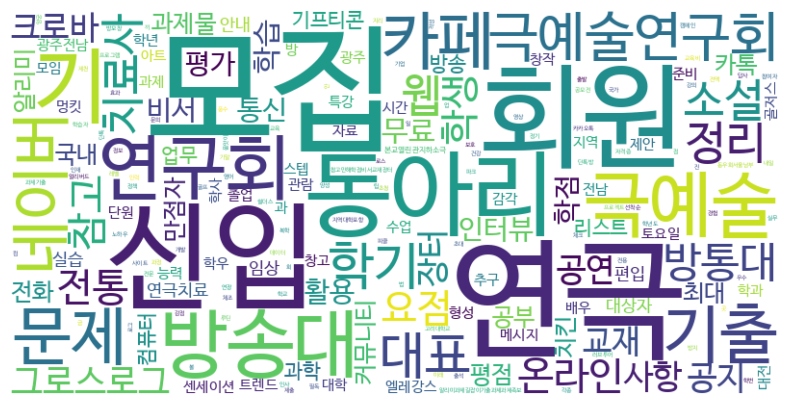

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## 단어 빈도를 바탕으로 워드클라우드 생성 및 표시
def plot_wordcloud(word_count):
    ## 워드 클라우드 생성
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' ## 한글 폰트 경로 지정
        ).generate_from_frequencies(word_count) # word_count의 빈도 정보를 이용하여 생성

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear') ## 이미지 표시
    plt.axis("off") ## 축 비활성화
    plt.show() ## 그래프 표시

## cs_df에서 단어 빈도 계산
word_count = get_word_count(cs_df)
## 워드클라우드 생성 및 표시
plot_wordcloud(word_count)

## 13-11 다른 학과의 워드 클라우드 생성

<IPython.core.display.Javascript object>

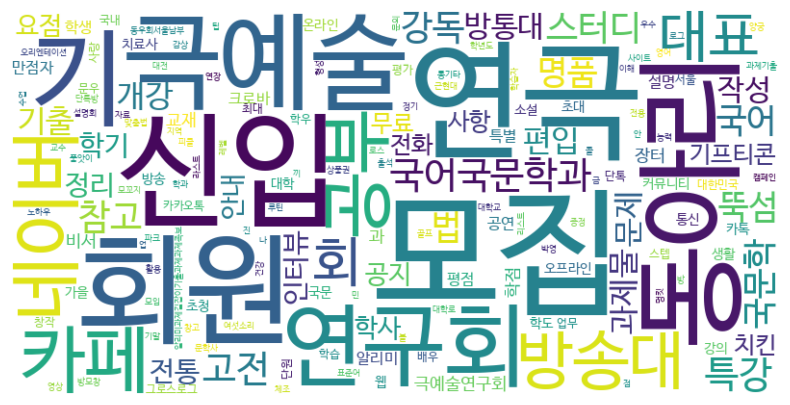

In [17]:
board_name = '국어국문학과'
board_url = 'https://korean.knou.ac.kr/korean/5323/subview.do'
board_titles = get_board_titles(url=board_url, pages=range(1,11), verbose=False)
ko_df = pd.DataFrame(data = {'제목': board_titles})
preprocessing_df(ko_df)
word_count = get_word_count(ko_df)
plot_wordcloud(word_count)

<IPython.core.display.Javascript object>

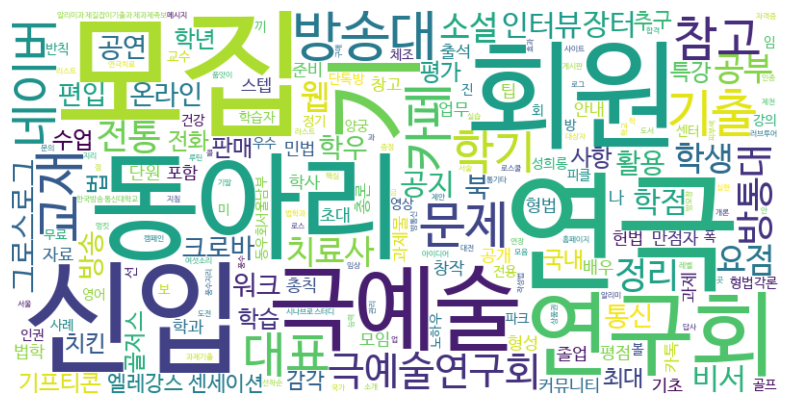

In [18]:
board_name = '법학과'
board_url = 'https://law.knou.ac.kr/law/5176/subview.do'
board_titles = get_board_titles(url=board_url, pages=range(1,11), verbose=False)
law_df = pd.DataFrame(data = {'제목': board_titles})
preprocessing_df(law_df)
word_count = get_word_count(law_df)
plot_wordcloud(word_count)

# 4. 텍스트 분류 및 시각화

## 13-12 VLLM 라이브러리 설치 및 LLM 모델 로드

주의
- 런타임 유형 : GPU
- 라이브러리 설치 및 모델 다운로드에 수 분(>6분)의 시간이 소요됩니다.


In [2]:
from vllm import LLM

## LLM 모델 로드 및 설정
llm = LLM(
    model="LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct",
    tensor_parallel_size=1,
    dtype="half",
   ## gpu_memory_utilization=0.9 ##0,9 RAM 용량 초과 0.5로 하자..
    gpu_memory_utilization=0.5,
    max_model_len=4096 ## 추가. 최대 32,768 디폴트 세팅시 메모리 초과
)

INFO 10-07 11:51:24 [config.py:3131] Downcasting torch.float32 to torch.float16.
INFO 10-07 11:51:24 [config.py:793] This model supports multiple tasks: {'reward', 'classify', 'generate', 'embed', 'score'}. Defaulting to 'generate'.
INFO 10-07 11:51:24 [llm_engine.py:230] Initializing a V0 LLM engine (v0.9.0) with config: model='LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', speculative_config=None, tokenizer='LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_backend=''), ob

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 10-07 11:52:05 [default_loader.py:280] Loading weights took 39.09 seconds
INFO 10-07 11:52:06 [model_runner.py:1202] Model loading took 4.5097 GiB and 39.400163 seconds
INFO 10-07 11:52:07 [worker.py:291] Memory profiling takes 1.40 seconds
INFO 10-07 11:52:07 [worker.py:291] the current vLLM instance can use total_gpu_memory (14.56GiB) x gpu_memory_utilization (0.50) = 7.28GiB
INFO 10-07 11:52:07 [worker.py:291] model weights take 4.51GiB; non_torch_memory takes 0.00GiB; PyTorch activation peak memory takes 0.95GiB; the rest of the memory reserved for KV Cache is 1.82GiB.
INFO 10-07 11:52:08 [executor_base.py:112] # cuda blocks: 1594, # CPU blocks: 3495
INFO 10-07 11:52:08 [executor_base.py:117] Maximum concurrency for 4096 tokens per request: 6.23x
INFO 10-07 11:52:17 [model_runner.py:1512] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in th

Capturing CUDA graph shapes:   0%|          | 0/35 [00:00<?, ?it/s]

INFO 10-07 11:52:59 [model_runner.py:1670] Graph capturing finished in 42 secs, took 0.19 GiB
INFO 10-07 11:52:59 [llm_engine.py:428] init engine (profile, create kv cache, warmup model) took 53.94 seconds


## 13-13 LLM 샘플링 파라미터 설정 및 프롬프트 생성

In [4]:
from vllm import SamplingParams ## SamplingParams 클래스 임포트

## 샘플링 파라미터 설정
sampling_params = SamplingParams(
    temperature=0.3, ## 생성 텍스트의 다양성 조절
    top_p=1.0, ## top_p 누적 확률 내에서 토큰 샘플링
    max_tokens=512, ## 생성될 최대 토큰 수
    frequency_penalty=0.5 ## 자주 나타나는 토큰에 대한 패널티
)

def format_prompt(user_input: str) -> str:
    ## 프롬프트 형식화 함수
    messages = [
        # 시스템 메시지 추가
        {"role":"system","content":"You ar EXAONE model from LG AI Research, a helpful assistant"},
        # 사용자 메시지 추가
        {"role":"user","content": user_input}
    ]
    return messages

## 프롬프트 생성
prompt = format_prompt("대한민국의 수도는 어디인가요? 수도에 여행하러간다면 어떤 즐길거리가 있을까요?")

## LLM을 사용하여 텍스트 생성
# chat 함수를 이용 (프롬프트와 샘플링 파라미터)
outputs = llm.chat(prompt, sampling_params)

## 생성된 텍스트 출력
print("\n생성된 텍스트:", outputs[0].outputs[0].text)

INFO 10-07 12:03:44 [chat_utils.py:419] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


생성된 텍스트: 대한민국의 수도는 **서울**입니다! 서울은 역사와 현대가 공존하는 매력적인 도시로, 다양한 관광 명소와 즐길거리를 제공합니다.

### 여행 즐길거리 추천:
1. **경복궁**: 조선 시대의 궁궐로, 아름다운 건축물과 정원을 감상할 수 있습니다. 특히 봄에는 벚꽃이 만발해 더욱 아름답습니다.
   
2. **북촌 한옥마을**: 전통 한옥들이 잘 보존되어 있어 한국의 전통 문화를 체험할 수 있는 곳입니다. 골목길을 따라 걷다 보면 옛 정취를 느낄 수 있습니다.

3. **인사동**: 한국의 전통문화와 예술 작품을 만나볼 수 있는 곳으로, 다양한 공예품과 갤러리가 있어 예술적 감각을 자극합니다.

4. **서울숲**: 도심 속 녹지 공간으로 자연을 즐기며 산책하거나 피크닉을 즐길 수 있습니다. 또한 다양한 야외 활동 시설이 마련되어 있어 가족 단위 여행객에게 인기가 많습니다.

5. **N서울타워 (서울스카이)**: 서울의 전경을 한눈에 볼 수 있는 전망대입니다. 밤에는 특히 아름다운 야경으로 유명합니다.

6. **한강공원**: 한강변을 따라 걷거나 자전거 타기 좋은 코스가 많아 운동과 휴식을 동시에 즐길 수 있습니다. 특히 가을이면 단풍이 아름다워 사진 촬영 명소로도 인기가 높습니다.

7. **명동 및 동대문 디자인 플라자 (DDP)**: 쇼핑과 문화 체험이 어우러진 지역으로, 현대적인 디자인 건축물인 DDP를 방문해보세요. 다양한 브랜드 매장과 전시회가 열려있어 쇼핑과 예술 감상 모두 가능합니다.

이러한 장소들은 서울의 다채로운 면모를 경험할 수 있게 해 줄 것입니다!


## 13-14 LLM 기반 분류 프롬프트 및 함수 정의

In [6]:
## 분류 프롬프트 형식화 함수
def format_classifier_prompt(board_title, title) -> str:
    messages = [
        {"role": "system", "content": "You are EXAONE model from LG AI Research, a helpful assistant."},
        {"role": "user", "content": """주어진 글의 제목을 분류하는 AI 모델입니다.
분류 클래스는 학사/전공, 학생활동, 외부정보로 나뉘어집니다.
- 학사/전공: 교재, 과제, 시험 등 학업 및 전공 관련 내용
- 학생활동: 동아리, 스터디, 모임 등 학생들의 자발적 활동
- 외부정보: 취업, 공모전, 행사 등 외부 정보"""},
        {"role": "user", "content": """예시)
전공명: 컴퓨터학과, 제목: 프로그래밍 과제 질문 -> 학사/전공
전공명: 컴퓨터학과, 제목: 알고리즘 스터디 모집 -> 학생활동
전공명: 컴퓨터학과, 제목: IT 취업 박람회 -> 외부정보"""},
        {"role": "user", "content": f"전공명: {board_title}\n제목: {title}"}
    ]
    return messages

## 분류 수행 함수
def classify(major, title):
    prompt = format_classifier_prompt(major, title) ## 분류 프롬프트 생성
    outputs = llm.chat([prompt], sampling_params) ## LLM으로 분류 실행
    return outputs[0].outputs[0].text ## 분류 결과 텍스트 반환

In [7]:
classify('컴퓨터학과', '딥러닝 개발 중에 질문 있습니다.')

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

'제목: "딥러닝 개발 중에 질문 있습니다."\n\n**분류:** 학생활동  \n**설명:** 이 제목은 특정 전공인 컴퓨터학과 내에서 딥러닝 분야의 개발 과정에서 발생하는 질문을 다루고 있으며, 이는 학생들이 직접 참여하거나 관련 커뮤니티 내에서 정보를 공유하고 해결 방안을 모색하는 자발적인 활동에 해당합니다. 따라서 **학생활동**으로 분류됩니다.'

In [8]:
classify('컴퓨터학과', '연극 동아리 회원 모집!! 신규 단원 혜택! AI로 배우는 연극!')

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

'**분류 결과:** 학생활동  \n**설명:** 제목이 연극 동아리 회원 모집과 관련된 내용으로, 학생들의 자발적인 동아리 활동과 관련된 정보를 제공하고 있어 학생활동 분류에 해당합니다.'

## 13-15 분류 결과 파싱 함수 정의

In [9]:
def get_class(analysis_result):
    ## 분석 결과에서 분류 클래스 추출
    classes = ['학사/전공', '학생활동', '외부정보', '기타']
    classes_index = [analysis_result.find(cls) for cls in classes]

    min_index = float('inf')
    min_class = '기타'

    for i in range(len(classes)):
        current_index = classes_index[i]
        if current_index != -1 and current_index < min_index:
            min_index = current_index
            min_class = classes[i]

    return min_class

하... 메모리 부족

In [ ]:
## 컴퓨터과학과 제목 분류 헬퍼 함수 정의
def classify_cs(title):
  return classify('컴퓨터과학과', title)

## '제목' 컬럼에 분류 함수 적용하여 분석 결과 저장
cs_df['class_analysis'] = cs_df['제목'].apply(classify_cs)
## 분석 결과에서 최종 분류 클래스 추출하여 저장
cs_df['class'] = cs_df['class_analysis'].apply(get_class)

## 13-17 분류 결과 시각화

In [ ]:
def plot_class(df):
  ## 분류 클래스별 개수 계산 및 순서 재정렬
  class_counts = df['class'].value_counts().reindex(['학사/전공', '학생활동', '외부정보'])

  plt.figure(figsize=(8, 6)) ## 그래프 크기 설정
  plt.pie(class_counts,
          labels=class_counts.index,
          autopct='%.1f%%', ## 퍼센트 표시 형식
          startangle=90, ## 시작 각도 설정
          )

  plt.title('Class Distribution') ## 그래프 제목 설정
  plt.axis('equal') ## 원형 비율 유지
  plt.show() ## 그래프 표시

plot_class(cs_df)

## 13-18 다른 학과의 분류 결과 시각화

In [ ]:
def classify_ko(title):
  return classify('국어국문학과', title)

ko_df['class_analysis'] = ko_df['제목'].apply(classify_ko)
ko_df['class'] = ko_df['class_analysis'].apply(get_class)

def classify_law(title):
  return classify('법학과', title)

law_df['class_analysis'] = law_df['제목'].apply(classify_law)
law_df['class'] = law_df['class_analysis'].apply(get_class)

In [ ]:
plot_class(ko_df)

In [ ]:
plot_class(law_df)